## Setup

### 1. Verify the Colab GPU toolchain

In [ ]:
import os
import platform
import shutil
import subprocess

print("Python:", platform.python_version())
print("nvcc:", shutil.which("nvcc"))
print("nvidia-smi:", shutil.which("nvidia-smi"))

if shutil.which("nvidia-smi"):
    subprocess.run(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv"],
        check=True,
    )
else:
    raise RuntimeError("No NVIDIA GPU found. Enable a GPU under Runtime → Change runtime type.")

if not shutil.which("nvcc"):
    raise RuntimeError("nvcc is missing. Reconnect to a fresh Colab GPU runtime.")

Python: 3.12.13
nvcc: /usr/local/cuda/bin/nvcc
nvidia-smi: /opt/bin/nvidia-smi


## Steps

### 2. Write the complete C++/CUDA engine

The single translation unit makes the project easy to run in Colab. Look for `tiled_gemm_v1`, its optimized `tiled_gemm_v2` follow-up, `fused_layernorm`, `PinnedMemoryPool`/`InferenceStream`, and `BatchingEngine`.

In [ ]:
%%writefile mini_inference.cu
#include <cuda_runtime.h>
#include <cublas_v2.h>

#include <algorithm>
#include <atomic>
#include <chrono>
#include <cmath>
#include <condition_variable>
#include <cstdint>
#include <cstdio>
#include <cstdlib>
#include <deque>
#include <fstream>
#include <future>
#include <iomanip>
#include <iostream>
#include <memory>
#include <mutex>
#include <numeric>
#include <random>
#include <stdexcept>
#include <string>
#include <thread>
#include <unordered_map>
#include <utility>
#include <vector>

#define CUDA_CHECK(call)                                                        \
  do {                                                                          \
    cudaError_t status_ = (call);                                                \
    if (status_ != cudaSuccess) {                                                \
      throw std::runtime_error(std::string("CUDA error at ") + __FILE__ + ":" + \
                               std::to_string(__LINE__) + ": " +               \
                               cudaGetErrorString(status_));                     \
    }                                                                            \
  } while (0)

#define CUBLAS_CHECK(call)                                                       \
  do {                                                                           \
    cublasStatus_t status_ = (call);                                              \
    if (status_ != CUBLAS_STATUS_SUCCESS) {                                       \
      throw std::runtime_error(std::string("cuBLAS error at ") + __FILE__ + ":" + \
                               std::to_string(__LINE__) + ": status " +          \
                               std::to_string(static_cast<int>(status_)));        \
    }                                                                             \
  } while (0)

constexpr int BASE_TILE = 16;
constexpr int OPT_TILE = 32;
constexpr int OPT_BLOCK = 16;
constexpr int LN_THREADS = 256;

// Row-major C[M,N] = A[M,K] * B[K,N]. Each block computes one 16x16 tile.
__global__ void tiled_gemm_v1(const float* __restrict__ A,
                              const float* __restrict__ B,
                              float* __restrict__ C,
                              int M, int N, int K) {
  __shared__ float As[BASE_TILE][BASE_TILE];
  __shared__ float Bs[BASE_TILE][BASE_TILE];
  const int row = blockIdx.y * BASE_TILE + threadIdx.y;
  const int col = blockIdx.x * BASE_TILE + threadIdx.x;
  float acc = 0.0f;

  for (int tile = 0; tile < (K + BASE_TILE - 1) / BASE_TILE; ++tile) {
    const int a_col = tile * BASE_TILE + threadIdx.x;
    const int b_row = tile * BASE_TILE + threadIdx.y;
    As[threadIdx.y][threadIdx.x] =
        (row < M && a_col < K) ? A[row * K + a_col] : 0.0f;
    Bs[threadIdx.y][threadIdx.x] =
        (b_row < K && col < N) ? B[b_row * N + col] : 0.0f;
    __syncthreads();

#pragma unroll
    for (int k = 0; k < BASE_TILE; ++k) {
      acc += As[threadIdx.y][k] * Bs[k][threadIdx.x];
    }
    __syncthreads();
  }
  if (row < M && col < N) C[row * N + col] = acc;
}

// Optimization pass: each 16x16 thread block computes a 32x32 output tile.
// Each thread accumulates a 2x2 register tile, increasing data reuse, while
// aligned float4 global loads reduce load instructions. Scalar fallbacks keep
// the kernel correct for dimensions that are not multiples of four.
__global__ void tiled_gemm_v2(const float* __restrict__ A,
                              const float* __restrict__ B,
                              float* __restrict__ C,
                              int M, int N, int K) {
  __shared__ float As[OPT_TILE][OPT_TILE];
  __shared__ float Bs[OPT_TILE][OPT_TILE];

  const int tx = threadIdx.x;
  const int ty = threadIdx.y;
  const int thread_id = ty * OPT_BLOCK + tx;
  const int load_row = thread_id / (OPT_TILE / 4);
  const int load_col = (thread_id % (OPT_TILE / 4)) * 4;
  const int row_base = blockIdx.y * OPT_TILE;
  const int col_base = blockIdx.x * OPT_TILE;
  const int row0 = row_base + ty;
  const int row1 = row0 + OPT_BLOCK;
  const int col0 = col_base + tx;
  const int col1 = col0 + OPT_BLOCK;

  float acc00 = 0.0f;
  float acc01 = 0.0f;
  float acc10 = 0.0f;
  float acc11 = 0.0f;

  for (int tile_start = 0; tile_start < K; tile_start += OPT_TILE) {
    const int a_row = row_base + load_row;
    const int a_col = tile_start + load_col;
    const int b_row = tile_start + load_row;
    const int b_col = col_base + load_col;
    float a_values[4] = {0.0f, 0.0f, 0.0f, 0.0f};
    float b_values[4] = {0.0f, 0.0f, 0.0f, 0.0f};

    if (a_row < M && a_col + 3 < K && K % 4 == 0) {
      const float4 packed =
          *reinterpret_cast<const float4*>(A + a_row * K + a_col);
      a_values[0] = packed.x;
      a_values[1] = packed.y;
      a_values[2] = packed.z;
      a_values[3] = packed.w;
    } else if (a_row < M) {
#pragma unroll
      for (int element = 0; element < 4; ++element) {
        if (a_col + element < K) {
          a_values[element] = A[a_row * K + a_col + element];
        }
      }
    }
    if (b_row < K && b_col + 3 < N && N % 4 == 0) {
      const float4 packed =
          *reinterpret_cast<const float4*>(B + b_row * N + b_col);
      b_values[0] = packed.x;
      b_values[1] = packed.y;
      b_values[2] = packed.z;
      b_values[3] = packed.w;
    } else if (b_row < K) {
#pragma unroll
      for (int element = 0; element < 4; ++element) {
        if (b_col + element < N) {
          b_values[element] = B[b_row * N + b_col + element];
        }
      }
    }

#pragma unroll
    for (int element = 0; element < 4; ++element) {
      As[load_row][load_col + element] = a_values[element];
      Bs[load_row][load_col + element] = b_values[element];
    }
    __syncthreads();

#pragma unroll
    for (int k = 0; k < OPT_TILE; ++k) {
      const float a0 = As[ty][k];
      const float a1 = As[ty + OPT_BLOCK][k];
      const float b0 = Bs[k][tx];
      const float b1 = Bs[k][tx + OPT_BLOCK];
      acc00 += a0 * b0;
      acc01 += a0 * b1;
      acc10 += a1 * b0;
      acc11 += a1 * b1;
    }
    __syncthreads();
  }

  if (row0 < M && col0 < N) C[row0 * N + col0] = acc00;
  if (row0 < M && col1 < N) C[row0 * N + col1] = acc01;
  if (row1 < M && col0 < N) C[row1 * N + col0] = acc10;
  if (row1 < M && col1 < N) C[row1 * N + col1] = acc11;
}

__inline__ __device__ float warp_sum(float value) {
  for (int offset = warpSize / 2; offset > 0; offset /= 2) {
    value += __shfl_down_sync(0xffffffff, value, offset);
  }
  return value;
}

// One block per row. Mean, variance, affine scale, and shift are fused into one
// kernel, so the GEMM output is read once and the normalized output written once.
__global__ void fused_layernorm(const float* __restrict__ input,
                                const float* __restrict__ gamma,
                                const float* __restrict__ beta,
                                float* __restrict__ output,
                                int rows, int cols, float epsilon) {
  const int row = blockIdx.x;
  if (row >= rows) return;

  float local_sum = 0.0f;
  float local_sq_sum = 0.0f;
  for (int col = threadIdx.x; col < cols; col += blockDim.x) {
    const float value = input[row * cols + col];
    local_sum += value;
    local_sq_sum += value * value;
  }
  local_sum = warp_sum(local_sum);
  local_sq_sum = warp_sum(local_sq_sum);

  __shared__ float warp_sums[32];
  __shared__ float warp_sq_sums[32];
  __shared__ float mean;
  __shared__ float inv_std;
  const int lane = threadIdx.x & 31;
  const int warp = threadIdx.x >> 5;
  if (lane == 0) {
    warp_sums[warp] = local_sum;
    warp_sq_sums[warp] = local_sq_sum;
  }
  __syncthreads();

  if (warp == 0) {
    const int warp_count = (blockDim.x + 31) / 32;
    float block_sum = lane < warp_count ? warp_sums[lane] : 0.0f;
    float block_sq_sum = lane < warp_count ? warp_sq_sums[lane] : 0.0f;
    block_sum = warp_sum(block_sum);
    block_sq_sum = warp_sum(block_sq_sum);
    if (lane == 0) {
      mean = block_sum / cols;
      const float variance = fmaxf(block_sq_sum / cols - mean * mean, 0.0f);
      inv_std = rsqrtf(variance + epsilon);
    }
  }
  __syncthreads();

  for (int col = threadIdx.x; col < cols; col += blockDim.x) {
    const float normalized = (input[row * cols + col] - mean) * inv_std;
    output[row * cols + col] = normalized * gamma[col] + beta[col];
  }
}

void launch_gemm_v1(const float* A, const float* B, float* C,
                    int M, int N, int K, cudaStream_t stream) {
  const dim3 block(BASE_TILE, BASE_TILE);
  const dim3 grid((N + BASE_TILE - 1) / BASE_TILE,
                  (M + BASE_TILE - 1) / BASE_TILE);
  tiled_gemm_v1<<<grid, block, 0, stream>>>(A, B, C, M, N, K);
  CUDA_CHECK(cudaGetLastError());
}

void launch_gemm(const float* A, const float* B, float* C,
                 int M, int N, int K, cudaStream_t stream) {
  const dim3 block(OPT_BLOCK, OPT_BLOCK);
  const dim3 grid((N + OPT_TILE - 1) / OPT_TILE,
                  (M + OPT_TILE - 1) / OPT_TILE);
  tiled_gemm_v2<<<grid, block, 0, stream>>>(A, B, C, M, N, K);
  CUDA_CHECK(cudaGetLastError());
}

void launch_layernorm(const float* input, const float* gamma, const float* beta,
                      float* output, int rows, int cols, cudaStream_t stream) {
  fused_layernorm<<<rows, LN_THREADS, 0, stream>>>(
      input, gamma, beta, output, rows, cols, 1e-5f);
  CUDA_CHECK(cudaGetLastError());
}

class PinnedMemoryPool {
 public:
  PinnedMemoryPool() = default;
  PinnedMemoryPool(const PinnedMemoryPool&) = delete;
  PinnedMemoryPool& operator=(const PinnedMemoryPool&) = delete;

  void* acquire(std::size_t bytes) {
    std::lock_guard<std::mutex> lock(mu_);
    auto& bucket = free_[bytes];
    if (!bucket.empty()) {
      void* pointer = bucket.back();
      bucket.pop_back();
      ++reuse_hits_;
      return pointer;
    }
    void* pointer = nullptr;
    CUDA_CHECK(cudaHostAlloc(&pointer, bytes, cudaHostAllocDefault));
    ++allocations_;
    return pointer;
  }

  void release(void* pointer, std::size_t bytes) {
    if (!pointer) return;
    std::lock_guard<std::mutex> lock(mu_);
    free_[bytes].push_back(pointer);
  }

  std::size_t allocations() const { return allocations_.load(); }
  std::size_t reuse_hits() const { return reuse_hits_.load(); }
  void record_buffer_use() { ++buffer_uses_; }
  std::size_t buffer_uses() const { return buffer_uses_.load(); }

  ~PinnedMemoryPool() {
    for (auto& [bytes, pointers] : free_) {
      (void)bytes;
      for (void* pointer : pointers) cudaFreeHost(pointer);
    }
  }

 private:
  std::mutex mu_;
  std::unordered_map<std::size_t, std::vector<void*>> free_;
  std::atomic<std::size_t> allocations_{0};
  std::atomic<std::size_t> reuse_hits_{0};
  std::atomic<std::size_t> buffer_uses_{0};
};

struct Model {
  int input_dim;
  int output_dim;
  float* weights = nullptr;
  float* gamma = nullptr;
  float* beta = nullptr;

  Model(int input_dim_, int output_dim_)
      : input_dim(input_dim_), output_dim(output_dim_) {
    std::mt19937 generator(7);
    std::normal_distribution<float> weight_dist(0.0f, 0.02f);
    std::vector<float> host_weights(input_dim * output_dim);
    std::generate(host_weights.begin(), host_weights.end(),
                  [&] { return weight_dist(generator); });
    std::vector<float> host_gamma(output_dim, 1.0f);
    std::vector<float> host_beta(output_dim, 0.0f);
    CUDA_CHECK(cudaMalloc(&weights, host_weights.size() * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&gamma, host_gamma.size() * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&beta, host_beta.size() * sizeof(float)));
    CUDA_CHECK(cudaMemcpy(weights, host_weights.data(),
                          host_weights.size() * sizeof(float),
                          cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(gamma, host_gamma.data(),
                          host_gamma.size() * sizeof(float),
                          cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(beta, host_beta.data(),
                          host_beta.size() * sizeof(float),
                          cudaMemcpyHostToDevice));
  }

  ~Model() {
    cudaFree(weights);
    cudaFree(gamma);
    cudaFree(beta);
  }
};

// A stream-owned execution slot. Pinned host buffers make cudaMemcpyAsync truly
// asynchronous; several slots can overlap H2D, kernels, and D2H.
class InferenceStream {
 public:
  InferenceStream(PinnedMemoryPool& pool, const Model& model, int max_batch)
      : pool_(pool), model_(model), max_batch_(max_batch) {
    input_bytes_ = static_cast<std::size_t>(max_batch_) * model_.input_dim * sizeof(float);
    output_bytes_ = static_cast<std::size_t>(max_batch_) * model_.output_dim * sizeof(float);
    host_input_ = static_cast<float*>(pool_.acquire(input_bytes_));
    host_output_ = static_cast<float*>(pool_.acquire(output_bytes_));
    CUDA_CHECK(cudaMalloc(&device_input_, input_bytes_));
    CUDA_CHECK(cudaMalloc(&device_gemm_, output_bytes_));
    CUDA_CHECK(cudaMalloc(&device_output_, output_bytes_));
    CUDA_CHECK(cudaStreamCreateWithFlags(&stream_, cudaStreamNonBlocking));
  }

  float* host_input() { return host_input_; }
  const float* host_output() const { return host_output_; }

  void enqueue(int batch_size) {
    if (batch_size <= 0 || batch_size > max_batch_) {
      throw std::invalid_argument("batch size is outside slot capacity");
    }
    pool_.record_buffer_use();
    active_batch_ = batch_size;
    const std::size_t input_bytes =
        static_cast<std::size_t>(batch_size) * model_.input_dim * sizeof(float);
    const std::size_t output_bytes =
        static_cast<std::size_t>(batch_size) * model_.output_dim * sizeof(float);
    CUDA_CHECK(cudaMemcpyAsync(device_input_, host_input_, input_bytes,
                               cudaMemcpyHostToDevice, stream_));
    launch_gemm(device_input_, model_.weights, device_gemm_, batch_size,
                model_.output_dim, model_.input_dim, stream_);
    launch_layernorm(device_gemm_, model_.gamma, model_.beta, device_output_,
                     batch_size, model_.output_dim, stream_);
    CUDA_CHECK(cudaMemcpyAsync(host_output_, device_output_, output_bytes,
                               cudaMemcpyDeviceToHost, stream_));
  }

  void wait() { CUDA_CHECK(cudaStreamSynchronize(stream_)); }

  ~InferenceStream() {
    if (stream_) cudaStreamSynchronize(stream_);
    cudaStreamDestroy(stream_);
    cudaFree(device_input_);
    cudaFree(device_gemm_);
    cudaFree(device_output_);
    pool_.release(host_input_, input_bytes_);
    pool_.release(host_output_, output_bytes_);
  }

 private:
  PinnedMemoryPool& pool_;
  const Model& model_;
  int max_batch_;
  int active_batch_ = 0;
  std::size_t input_bytes_ = 0;
  std::size_t output_bytes_ = 0;
  float* host_input_ = nullptr;
  float* host_output_ = nullptr;
  float* device_input_ = nullptr;
  float* device_gemm_ = nullptr;
  float* device_output_ = nullptr;
  cudaStream_t stream_ = nullptr;
};

struct InferenceResult {
  std::vector<float> output;
  double latency_ms = 0.0;
  int batch_size = 0;
};

struct Request {
  std::vector<float> input;
  std::promise<InferenceResult> promise;
  std::chrono::steady_clock::time_point submitted;
};

// Each worker builds a dynamic micro-batch and owns one CUDA stream. This keeps
// queue coordination on the CPU while allowing independent batches to overlap on
// the GPU. The timeout prevents low-traffic requests from waiting forever.
class BatchingEngine {
 public:
  BatchingEngine(PinnedMemoryPool& pool, const Model& model, int worker_count,
                 int max_batch, std::chrono::microseconds batch_timeout)
      : pool_(pool), model_(model), max_batch_(max_batch),
        batch_timeout_(batch_timeout) {
    for (int worker = 0; worker < worker_count; ++worker) {
      workers_.emplace_back(&BatchingEngine::worker_loop, this, worker);
    }
  }

  std::future<InferenceResult> submit(std::vector<float> input) {
    if (static_cast<int>(input.size()) != model_.input_dim) {
      throw std::invalid_argument("request input has the wrong width");
    }
    auto request = std::make_shared<Request>();
    request->input = std::move(input);
    request->submitted = std::chrono::steady_clock::now();
    std::future<InferenceResult> future = request->promise.get_future();
    {
      std::lock_guard<std::mutex> lock(mu_);
      if (stopping_) throw std::runtime_error("submit called during shutdown");
      queue_.push_back(request);
    }
    cv_.notify_one();
    return future;
  }

  ~BatchingEngine() {
    {
      std::lock_guard<std::mutex> lock(mu_);
      stopping_ = true;
    }
    cv_.notify_all();
    for (auto& worker : workers_) worker.join();
  }

 private:
  void worker_loop(int worker_id) {
    (void)worker_id;
    try {
      InferenceStream slot(pool_, model_, max_batch_);
      while (true) {
        std::vector<std::shared_ptr<Request>> batch;
        {
          std::unique_lock<std::mutex> lock(mu_);
          cv_.wait(lock, [&] { return stopping_ || !queue_.empty(); });
          if (stopping_ && queue_.empty()) return;
          batch.push_back(queue_.front());
          queue_.pop_front();
          const auto deadline = std::chrono::steady_clock::now() + batch_timeout_;
          while (static_cast<int>(batch.size()) < max_batch_) {
            if (queue_.empty()) {
              cv_.wait_until(lock, deadline,
                             [&] { return stopping_ || !queue_.empty(); });
            }
            while (!queue_.empty() && static_cast<int>(batch.size()) < max_batch_) {
              batch.push_back(queue_.front());
              queue_.pop_front();
            }
            if (std::chrono::steady_clock::now() >= deadline || stopping_) break;
          }
        }

        for (std::size_t row = 0; row < batch.size(); ++row) {
          std::copy(batch[row]->input.begin(), batch[row]->input.end(),
                    slot.host_input() + row * model_.input_dim);
        }
        slot.enqueue(static_cast<int>(batch.size()));
        slot.wait();
        const auto completed = std::chrono::steady_clock::now();

        for (std::size_t row = 0; row < batch.size(); ++row) {
          InferenceResult result;
          const float* begin = slot.host_output() + row * model_.output_dim;
          result.output.assign(begin, begin + model_.output_dim);
          result.latency_ms =
              std::chrono::duration<double, std::milli>(completed - batch[row]->submitted)
                  .count();
          result.batch_size = static_cast<int>(batch.size());
          batch[row]->promise.set_value(std::move(result));
        }
      }
    } catch (...) {
      // Fail every queued request instead of leaving callers blocked.
      std::deque<std::shared_ptr<Request>> failed;
      {
        std::lock_guard<std::mutex> lock(mu_);
        stopping_ = true;
        failed.swap(queue_);
      }
      for (auto& request : failed) request->promise.set_exception(std::current_exception());
      cv_.notify_all();
    }
  }

  PinnedMemoryPool& pool_;
  const Model& model_;
  int max_batch_;
  std::chrono::microseconds batch_timeout_;
  std::mutex mu_;
  std::condition_variable cv_;
  std::deque<std::shared_ptr<Request>> queue_;
  bool stopping_ = false;
  std::vector<std::thread> workers_;
};

float max_abs_error(const std::vector<float>& a, const std::vector<float>& b) {
  float error = 0.0f;
  for (std::size_t index = 0; index < a.size(); ++index) {
    error = std::max(error, std::abs(a[index] - b[index]));
  }
  return error;
}

template <typename Function>
float benchmark_ms(Function&& function, int repetitions) {
  cudaEvent_t start = nullptr;
  cudaEvent_t stop = nullptr;
  CUDA_CHECK(cudaEventCreate(&start));
  CUDA_CHECK(cudaEventCreate(&stop));
  for (int warmup = 0; warmup < 10; ++warmup) function();
  CUDA_CHECK(cudaDeviceSynchronize());
  CUDA_CHECK(cudaEventRecord(start));
  for (int repetition = 0; repetition < repetitions; ++repetition) function();
  CUDA_CHECK(cudaEventRecord(stop));
  CUDA_CHECK(cudaEventSynchronize(stop));
  float elapsed_ms = 0.0f;
  CUDA_CHECK(cudaEventElapsedTime(&elapsed_ms, start, stop));
  CUDA_CHECK(cudaEventDestroy(start));
  CUDA_CHECK(cudaEventDestroy(stop));
  return elapsed_ms / repetitions;
}

struct Metric {
  std::string name;
  double value;
  std::string unit;
};

void write_metrics(const std::vector<Metric>& metrics,
                   const std::string& path = "benchmark_results.csv") {
  std::ofstream output(path);
  output << "metric,value,unit\n";
  output << std::setprecision(10);
  for (const auto& metric : metrics) {
    output << metric.name << ',' << metric.value << ',' << metric.unit << '\n';
  }
}

std::vector<float> cpu_layernorm(const std::vector<float>& input,
                                 const std::vector<float>& gamma,
                                 const std::vector<float>& beta,
                                 int rows, int cols) {
  std::vector<float> output(input.size());
  for (int row = 0; row < rows; ++row) {
    double sum = 0.0;
    double square_sum = 0.0;
    for (int col = 0; col < cols; ++col) {
      const float value = input[row * cols + col];
      sum += value;
      square_sum += static_cast<double>(value) * value;
    }
    const double mean = sum / cols;
    const double variance = std::max(square_sum / cols - mean * mean, 0.0);
    const double inv_std = 1.0 / std::sqrt(variance + 1e-5);
    for (int col = 0; col < cols; ++col) {
      output[row * cols + col] = static_cast<float>(
          (input[row * cols + col] - mean) * inv_std * gamma[col] + beta[col]);
    }
  }
  return output;
}

void print_device() {
  int device = 0;
  CUDA_CHECK(cudaGetDevice(&device));
  cudaDeviceProp properties{};
  CUDA_CHECK(cudaGetDeviceProperties(&properties, device));
  std::cout << "GPU: " << properties.name << " (SM " << properties.major << '.'
            << properties.minor << ", " << properties.multiProcessorCount
            << " SMs, " << properties.totalGlobalMem / (1024 * 1024)
            << " MiB)\n";

  int baseline_gemm_blocks = 0;
  int optimized_gemm_blocks = 0;
  int layernorm_blocks = 0;
  CUDA_CHECK(cudaOccupancyMaxActiveBlocksPerMultiprocessor(
      &baseline_gemm_blocks, tiled_gemm_v1, BASE_TILE * BASE_TILE, 0));
  CUDA_CHECK(cudaOccupancyMaxActiveBlocksPerMultiprocessor(
      &optimized_gemm_blocks, tiled_gemm_v2, OPT_BLOCK * OPT_BLOCK, 0));
  CUDA_CHECK(cudaOccupancyMaxActiveBlocksPerMultiprocessor(
      &layernorm_blocks, fused_layernorm, LN_THREADS, 0));
  const double baseline_gemm_occupancy =
      100.0 * baseline_gemm_blocks * BASE_TILE * BASE_TILE /
      properties.maxThreadsPerMultiProcessor;
  const double optimized_gemm_occupancy =
      100.0 * optimized_gemm_blocks * OPT_BLOCK * OPT_BLOCK /
      properties.maxThreadsPerMultiProcessor;
  const double layernorm_occupancy = 100.0 * layernorm_blocks * LN_THREADS /
                                     properties.maxThreadsPerMultiProcessor;
  std::cout << "Theoretical occupancy: GEMM v1=" << baseline_gemm_occupancy
            << "% GEMM v2=" << optimized_gemm_occupancy
            << "% LayerNorm=" << layernorm_occupancy << "%\n";
}

std::vector<Metric> run_kernel_benchmarks() {
  constexpr int M = 512;
  constexpr int N = 512;
  constexpr int K = 512;
  constexpr int repetitions = 100;
  std::mt19937 generator(42);
  std::uniform_real_distribution<float> distribution(-0.1f, 0.1f);
  std::vector<float> host_a(M * K);
  std::vector<float> host_b(K * N);
  std::generate(host_a.begin(), host_a.end(), [&] { return distribution(generator); });
  std::generate(host_b.begin(), host_b.end(), [&] { return distribution(generator); });

  float *device_a = nullptr, *device_b = nullptr, *device_baseline = nullptr;
  float *device_optimized = nullptr, *device_cublas = nullptr;
  CUDA_CHECK(cudaMalloc(&device_a, host_a.size() * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_b, host_b.size() * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_baseline, M * N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_optimized, M * N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_cublas, M * N * sizeof(float)));
  CUDA_CHECK(cudaMemcpy(device_a, host_a.data(), host_a.size() * sizeof(float),
                        cudaMemcpyHostToDevice));
  CUDA_CHECK(cudaMemcpy(device_b, host_b.data(), host_b.size() * sizeof(float),
                        cudaMemcpyHostToDevice));

  cublasHandle_t handle = nullptr;
  CUBLAS_CHECK(cublasCreate(&handle));
  const float alpha = 1.0f;
  const float beta = 0.0f;
  auto baseline_call = [&] {
    launch_gemm_v1(device_a, device_b, device_baseline, M, N, K, 0);
  };
  auto optimized_call = [&] {
    launch_gemm(device_a, device_b, device_optimized, M, N, K, 0);
  };
  // cuBLAS is column-major. Swapping A/B computes the row-major product.
  auto cublas_call = [&] {
    CUBLAS_CHECK(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N, N, M, K,
                            &alpha, device_b, N, device_a, K, &beta,
                            device_cublas, N));
  };
  baseline_call();
  optimized_call();
  cublas_call();
  CUDA_CHECK(cudaDeviceSynchronize());
  std::vector<float> baseline_output(M * N);
  std::vector<float> optimized_output(M * N);
  std::vector<float> cublas_output(M * N);
  CUDA_CHECK(cudaMemcpy(baseline_output.data(), device_baseline,
                        baseline_output.size() * sizeof(float),
                        cudaMemcpyDeviceToHost));
  CUDA_CHECK(cudaMemcpy(optimized_output.data(), device_optimized,
                        optimized_output.size() * sizeof(float),
                        cudaMemcpyDeviceToHost));
  CUDA_CHECK(cudaMemcpy(cublas_output.data(), device_cublas,
                        cublas_output.size() * sizeof(float), cudaMemcpyDeviceToHost));
  const float baseline_error = max_abs_error(baseline_output, cublas_output);
  const float optimized_error = max_abs_error(optimized_output, cublas_output);

  const float baseline_ms = benchmark_ms(baseline_call, repetitions);
  const float optimized_ms = benchmark_ms(optimized_call, repetitions);
  const float cublas_ms = benchmark_ms(cublas_call, repetitions);
  const double operations = 2.0 * M * N * K;
  const double baseline_tflops = operations / (baseline_ms * 1e9);
  const double optimized_tflops = operations / (optimized_ms * 1e9);
  const double cublas_tflops = operations / (cublas_ms * 1e9);
  const double optimized_percent_of_cublas =
      100.0 * optimized_tflops / cublas_tflops;
  const double optimization_speedup = baseline_ms / optimized_ms;
  const double gemm_bytes =
      static_cast<double>((M * K + K * N + M * N) * sizeof(float));
  const double optimized_effective_gbps = gemm_bytes / (optimized_ms * 1e6);

  constexpr int LN_ROWS = 4096;
  constexpr int LN_COLS = 512;
  std::vector<float> host_ln(LN_ROWS * LN_COLS);
  std::vector<float> host_gamma(LN_COLS);
  std::vector<float> host_beta(LN_COLS);
  std::generate(host_ln.begin(), host_ln.end(), [&] { return distribution(generator); });
  std::fill(host_gamma.begin(), host_gamma.end(), 1.1f);
  std::fill(host_beta.begin(), host_beta.end(), 0.1f);
  float *device_ln = nullptr, *device_gamma = nullptr, *device_beta = nullptr;
  float* device_ln_output = nullptr;
  CUDA_CHECK(cudaMalloc(&device_ln, host_ln.size() * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_gamma, host_gamma.size() * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_beta, host_beta.size() * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&device_ln_output, host_ln.size() * sizeof(float)));
  CUDA_CHECK(cudaMemcpy(device_ln, host_ln.data(), host_ln.size() * sizeof(float),
                        cudaMemcpyHostToDevice));
  CUDA_CHECK(cudaMemcpy(device_gamma, host_gamma.data(), host_gamma.size() * sizeof(float),
                        cudaMemcpyHostToDevice));
  CUDA_CHECK(cudaMemcpy(device_beta, host_beta.data(), host_beta.size() * sizeof(float),
                        cudaMemcpyHostToDevice));
  auto layernorm_call = [&] {
    launch_layernorm(device_ln, device_gamma, device_beta, device_ln_output,
                     LN_ROWS, LN_COLS, 0);
  };
  layernorm_call();
  CUDA_CHECK(cudaDeviceSynchronize());
  std::vector<float> gpu_ln(host_ln.size());
  CUDA_CHECK(cudaMemcpy(gpu_ln.data(), device_ln_output,
                        gpu_ln.size() * sizeof(float), cudaMemcpyDeviceToHost));
  const std::vector<float> reference_ln =
      cpu_layernorm(host_ln, host_gamma, host_beta, LN_ROWS, LN_COLS);
  const float layernorm_error = max_abs_error(gpu_ln, reference_ln);
  const float layernorm_ms = benchmark_ms(layernorm_call, repetitions);
  // Input + gamma + beta reads and one output write. Gamma/beta may be cached, so
  // this is an algorithmic/effective bandwidth rather than raw DRAM throughput.
  const double layernorm_bytes =
      static_cast<double>((2LL * LN_ROWS * LN_COLS + 2LL * LN_COLS) * sizeof(float));
  const double layernorm_gbps = layernorm_bytes / (layernorm_ms * 1e6);

  std::cout << std::fixed << std::setprecision(4);
  std::cout << "GEMM max |baseline-cuBLAS|: " << baseline_error << '\n';
  std::cout << "GEMM max |optimized-cuBLAS|: " << optimized_error << '\n';
  std::cout << "Baseline GEMM: " << baseline_ms << " ms, " << baseline_tflops
            << " TFLOP/s\n";
  std::cout << "Optimized GEMM: " << optimized_ms << " ms, "
            << optimized_tflops << " TFLOP/s, " << optimized_effective_gbps
            << " effective GB/s\n";
  std::cout << "cuBLAS SGEMM: " << cublas_ms << " ms, " << cublas_tflops
            << " TFLOP/s\n";
  std::cout << "Optimization uplift: " << optimization_speedup << "x\n";
  std::cout << "Optimized kernel reached " << optimized_percent_of_cublas
            << "% of cuBLAS throughput (cuBLAS is "
            << optimized_ms / cublas_ms << "x faster)\n";
  std::cout << "LayerNorm max |GPU-CPU|: " << layernorm_error << '\n';
  std::cout << "Fused LayerNorm: " << layernorm_ms << " ms, "
            << layernorm_gbps << " effective GB/s\n";

  cublasDestroy(handle);
  cudaFree(device_a);
  cudaFree(device_b);
  cudaFree(device_baseline);
  cudaFree(device_optimized);
  cudaFree(device_cublas);
  cudaFree(device_ln);
  cudaFree(device_gamma);
  cudaFree(device_beta);
  cudaFree(device_ln_output);

  return {
      {"baseline_gemm_max_abs_error", baseline_error, "absolute"},
      {"optimized_gemm_max_abs_error", optimized_error, "absolute"},
      {"baseline_gemm_ms", baseline_ms, "ms"},
      {"baseline_gemm_tflops", baseline_tflops, "TFLOP/s"},
      {"optimized_gemm_ms", optimized_ms, "ms"},
      {"optimized_gemm_tflops", optimized_tflops, "TFLOP/s"},
      {"optimized_gemm_effective_bandwidth", optimized_effective_gbps, "GB/s"},
      {"gemm_optimization_speedup", optimization_speedup, "x"},
      {"cublas_sgemm_ms", cublas_ms, "ms"},
      {"cublas_sgemm_tflops", cublas_tflops, "TFLOP/s"},
      {"optimized_percent_of_cublas", optimized_percent_of_cublas, "%"},
      {"cublas_speedup_over_optimized", optimized_ms / cublas_ms, "x"},
      {"layernorm_max_abs_error", layernorm_error, "absolute"},
      {"fused_layernorm_ms", layernorm_ms, "ms"},
      {"fused_layernorm_effective_bandwidth", layernorm_gbps, "GB/s"},
  };
}

std::vector<Metric> run_runtime_benchmarks(PinnedMemoryPool& pool,
                                           const Model& model) {
  constexpr int max_batch = 32;
  constexpr int pipeline_batches = 500;
  constexpr int request_count = 10000;
  std::mt19937 generator(123);
  std::uniform_real_distribution<float> distribution(-1.0f, 1.0f);

  // Compare one slot with two. With two slots, H2D/kernel/D2H work from adjacent
  // batches can overlap when the GPU has copy engines and scheduling capacity.
  auto run_pipeline = [&](int slot_count) {
    std::vector<std::unique_ptr<InferenceStream>> slots;
    std::vector<bool> busy(slot_count, false);
    for (int slot = 0; slot < slot_count; ++slot) {
      slots.emplace_back(std::make_unique<InferenceStream>(pool, model, max_batch));
      float* input = slots.back()->host_input();
      for (int index = 0; index < max_batch * model.input_dim; ++index) {
        input[index] = distribution(generator);
      }
      slots.back()->enqueue(max_batch);
      slots.back()->wait();
    }
    const auto start = std::chrono::steady_clock::now();
    for (int batch = 0; batch < pipeline_batches; ++batch) {
      const int slot_index = batch % slot_count;
      if (busy[slot_index]) slots[slot_index]->wait();
      slots[slot_index]->enqueue(max_batch);
      busy[slot_index] = true;
    }
    for (int slot = 0; slot < slot_count; ++slot) {
      if (busy[slot]) slots[slot]->wait();
    }
    const double seconds =
        std::chrono::duration<double>(std::chrono::steady_clock::now() - start)
            .count();
    return pipeline_batches * max_batch / seconds;
  };
  const double one_stream_requests_per_second = run_pipeline(1);
  const double two_stream_requests_per_second = run_pipeline(2);
  const double stream_overlap_speedup =
      two_stream_requests_per_second / one_stream_requests_per_second;

  std::vector<std::future<InferenceResult>> futures;
  futures.reserve(request_count);
  const auto batching_start = std::chrono::steady_clock::now();
  {
    BatchingEngine engine(pool, model, 2, max_batch,
                          std::chrono::microseconds(750));
    for (int request = 0; request < request_count; ++request) {
      std::vector<float> input(model.input_dim);
      std::generate(input.begin(), input.end(), [&] { return distribution(generator); });
      futures.push_back(engine.submit(std::move(input)));
    }

    std::vector<double> latencies;
    std::vector<int> observed_batches;
    latencies.reserve(request_count);
    for (auto& future : futures) {
      InferenceResult result = future.get();
      latencies.push_back(result.latency_ms);
      observed_batches.push_back(result.batch_size);
    }
    const double batching_seconds =
        std::chrono::duration<double>(std::chrono::steady_clock::now() - batching_start)
            .count();
    std::ofstream latency_output("request_latencies.csv");
    latency_output << "request_id,latency_ms,batch_size\n";
    latency_output << std::setprecision(10);
    for (std::size_t index = 0; index < latencies.size(); ++index) {
      latency_output << index << ',' << latencies[index] << ','
                     << observed_batches[index] << '\n';
    }
    std::sort(latencies.begin(), latencies.end());
    const auto percentile = [&](double fraction) {
      const std::size_t index = static_cast<std::size_t>(
          std::ceil(fraction * latencies.size()) - 1);
      return latencies[std::min(index, latencies.size() - 1)];
    };
    const double p50 = percentile(0.50);
    const double p99 = percentile(0.99);
    const double average_batch =
        std::accumulate(observed_batches.begin(), observed_batches.end(), 0.0) /
        observed_batches.size();
    const double batching_requests_per_second = request_count / batching_seconds;

    std::cout << "One-stream end-to-end throughput: "
              << one_stream_requests_per_second << " requests/s\n";
    std::cout << "Two-stream end-to-end throughput: "
              << two_stream_requests_per_second << " requests/s ("
              << stream_overlap_speedup << "x vs one stream)\n";
    std::cout << "Dynamic batching throughput: " << batching_requests_per_second
              << " requests/s\n";
    std::cout << "Queue-to-result latency p50=" << p50 << " ms p99=" << p99
              << " ms\n";
    std::cout << "Average observed batch size: " << average_batch << '\n';
    std::cout << "Pinned memory: " << pool.allocations()
              << " cudaHostAlloc calls across " << pool.buffer_uses()
              << " batch-buffer uses; no allocation in the timed hot path\n";

    return {
        {"one_stream_pipeline_throughput", one_stream_requests_per_second,
         "requests/s"},
        {"two_stream_pipeline_throughput", two_stream_requests_per_second,
         "requests/s"},
        {"two_stream_speedup", stream_overlap_speedup, "x"},
        {"batching_throughput", batching_requests_per_second, "requests/s"},
        {"latency_p50", p50, "ms"},
        {"latency_p99", p99, "ms"},
        {"average_batch_size", average_batch, "requests"},
        {"pinned_pool_cuda_host_alloc_calls",
         static_cast<double>(pool.allocations()), "calls"},
        {"pinned_buffer_batch_uses", static_cast<double>(pool.buffer_uses()),
         "uses"},
    };
  }
}

void profile_once() {
  constexpr int M = 512;
  constexpr int N = 512;
  constexpr int K = 512;
  float *a = nullptr, *b = nullptr, *c = nullptr, *output = nullptr;
  float *gamma = nullptr, *beta = nullptr;
  CUDA_CHECK(cudaMalloc(&a, M * K * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&b, K * N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&c, M * N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&output, M * N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&gamma, N * sizeof(float)));
  CUDA_CHECK(cudaMalloc(&beta, N * sizeof(float)));
  launch_gemm_v1(a, b, c, M, N, K, 0);
  launch_gemm(a, b, c, M, N, K, 0);
  launch_layernorm(c, gamma, beta, output, M, N, 0);
  CUDA_CHECK(cudaDeviceSynchronize());
  cudaFree(a);
  cudaFree(b);
  cudaFree(c);
  cudaFree(output);
  cudaFree(gamma);
  cudaFree(beta);
}

int main(int argc, char** argv) {
  try {
    print_device();
    if (argc > 1 && std::string(argv[1]) == "--profile") {
      profile_once();
      return 0;
    }

    std::vector<Metric> metrics = run_kernel_benchmarks();
    PinnedMemoryPool pool;
    {
      Model model(512, 512);
      std::vector<Metric> runtime_metrics = run_runtime_benchmarks(pool, model);
      metrics.insert(metrics.end(), runtime_metrics.begin(), runtime_metrics.end());
    }
    write_metrics(metrics);

    const auto metric_value = [&](const std::string& name) {
      const auto found = std::find_if(
          metrics.begin(), metrics.end(),
          [&](const Metric& metric) { return metric.name == name; });
      if (found == metrics.end()) throw std::runtime_error("missing metric: " + name);
      return found->value;
    };
    const bool gemm_ok =
        metric_value("baseline_gemm_max_abs_error") < 5e-3 &&
        metric_value("optimized_gemm_max_abs_error") < 5e-3;
    const bool layernorm_ok = metric_value("layernorm_max_abs_error") < 5e-3;
    std::cout << (gemm_ok && layernorm_ok ? "CHECKS PASSED" : "CHECKS FAILED")
              << '\n';
    return gemm_ok && layernorm_ok ? 0 : 2;
  } catch (const std::exception& error) {
    std::cerr << "fatal: " << error.what() << '\n';
    return 1;
  }
}

Overwriting mini_inference.cu


### 3. Compile with optimization and useful profiler line information

In [ ]:
!nvcc -O3 -std=c++17 -lineinfo -Xcompiler=-pthread mini_inference.cu -lcublas -o mini_inference
!ls -lh mini_inference mini_inference.cu

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
-rwxr-xr-x 1 root root 1.2M Aug 20 17:53 mini_inference
-rw-r--r-- 1 root root  38K Aug 20 17:53 mini_inference.cu


### 4. Run correctness checks and benchmarks

This typically takes under a minute. It writes `benchmark_results.csv` and `request_latencies.csv`. Treat the results as specific to the current Colab allocation; GPU model, clocks, thermal state, and neighboring workloads all matter.

In [ ]:
import subprocess

run = subprocess.run(
    ["./mini_inference"],
    text=True,
    capture_output=True,
    timeout=180,
)
print(run.stdout)
if run.stderr:
    print(run.stderr)
run.check_returncode()
assert "CHECKS PASSED" in run.stdout

GPU: Tesla T4 (SM 7.5, 40 SMs, 14912 MiB)
Theoretical occupancy: GEMM v1=100% GEMM v2=100% LayerNorm=100%
GEMM max |baseline-cuBLAS|: 0.0000
GEMM max |optimized-cuBLAS|: 0.0000
Baseline GEMM: 0.4871 ms, 0.5511 TFLOP/s
Optimized GEMM: 0.2852 ms, 0.9413 TFLOP/s, 11.0308 effective GB/s
cuBLAS SGEMM: 0.0862 ms, 3.1142 TFLOP/s
Optimization uplift: 1.7081x
Optimized kernel reached 30.2257% of cuBLAS throughput (cuBLAS is 3.3084x faster)
LayerNorm max |GPU-CPU|: 0.0000
Fused LayerNorm: 0.1155 ms, 145.2579 effective GB/s
One-stream end-to-end throughput: 431147.7403 requests/s
Two-stream end-to-end throughput: 1088948.0687 requests/s (2.5257x vs one stream)
Dynamic batching throughput: 119102.1239 requests/s
Queue-to-result latency p50=0.3087 ms p99=0.8325 ms
Average observed batch size: 31.6298
Pinned memory: 4 cudaHostAlloc calls across 1320 batch-buffer uses; no allocation in the timed hot path
CHECKS PASSED



### 5. Inspect and visualize the report

The first plot compares GEMM latency. The second reports serving latency, and the third shows the raw latency distribution. Results remain in CSV files for later comparison across GPU types or kernel revisions.

,metric,value,unit
0,baseline_gemm_max_abs_error,0.000000e+00,absolute
1,optimized_gemm_max_abs_error,0.000000e+00,absolute
2,baseline_gemm_ms,4.871168e-01,ms
3,baseline_gemm_tflops,5.510700e-01,TFLOP/s
4,optimized_gemm_ms,2.851776e-01,ms
5,optimized_gemm_tflops,9.412923e-01,TFLOP/s
6,optimized_gemm_effective_bandwidth,1.103077e+01,GB/s
7,gemm_optimization_speedup,1.708117e+00,x
8,cublas_sgemm_ms,8.619680e-02,ms
9,cublas_sgemm_tflops,3.114216e+00,TFLOP/s


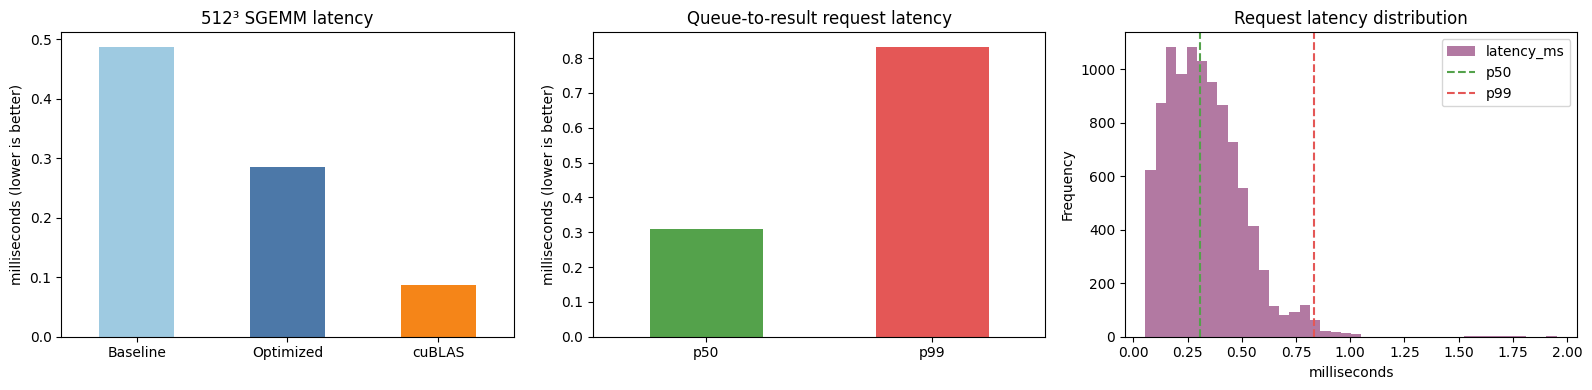

Optimization uplift: 1.71x
Optimized kernel reached 30.2% of cuBLAS throughput
cuBLAS speedup over optimized: 3.31x
Two-stream speedup: 2.53x
p99 / p50 latency ratio: 2.70x
Average dynamic batch size: 31.6
Pinned pool: 4 cudaHostAlloc calls across 1320 batch-buffer uses


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv("benchmark_results.csv")
latency_samples = pd.read_csv("request_latencies.csv")
display(metrics)

values = metrics.set_index("metric")["value"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

gemm_ms = values[["baseline_gemm_ms", "optimized_gemm_ms", "cublas_sgemm_ms"]]
gemm_ms.index = ["Baseline", "Optimized", "cuBLAS"]
gemm_ms.plot.bar(ax=axes[0], color=["#9ECAE1", "#4C78A8", "#F58518"])
axes[0].set_title("512³ SGEMM latency")
axes[0].set_ylabel("milliseconds (lower is better)")
axes[0].tick_params(axis="x", rotation=0)

latency = values[["latency_p50", "latency_p99"]]
latency.index = ["p50", "p99"]
latency.plot.bar(ax=axes[1], color=["#54A24B", "#E45756"])
axes[1].set_title("Queue-to-result request latency")
axes[1].set_ylabel("milliseconds (lower is better)")
axes[1].tick_params(axis="x", rotation=0)

latency_samples["latency_ms"].plot.hist(bins=40, ax=axes[2], color="#B279A2")
axes[2].axvline(values["latency_p50"], color="#54A24B", linestyle="--", label="p50")
axes[2].axvline(values["latency_p99"], color="#E45756", linestyle="--", label="p99")
axes[2].set_title("Request latency distribution")
axes[2].set_xlabel("milliseconds")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Optimization uplift: {values['gemm_optimization_speedup']:.2f}x")
print(f"Optimized kernel reached {values['optimized_percent_of_cublas']:.1f}% of cuBLAS throughput")
print(f"cuBLAS speedup over optimized: {values['cublas_speedup_over_optimized']:.2f}x")
print(f"Two-stream speedup: {values['two_stream_speedup']:.2f}x")
print(f"p99 / p50 latency ratio: {values['latency_p99'] / values['latency_p50']:.2f}x")
print(f"Average dynamic batch size: {values['average_batch_size']:.1f}")
print(
    f"Pinned pool: {values['pinned_pool_cuda_host_alloc_calls']:.0f} cudaHostAlloc calls "
    f"across {values['pinned_buffer_batch_uses']:.0f} batch-buffer uses"
)

## Checks

### 6. Profile the kernels with Nsight Compute

`cudaOccupancyMaxActiveBlocksPerMultiprocessor` above reports **theoretical occupancy** from launch configuration and resource limits. Nsight Compute measures achieved occupancy and DRAM traffic. The executable’s `--profile` mode launches exactly one baseline GEMM, one optimized GEMM, and one LayerNorm so profiling stays focused.


In [ ]:
import shutil

ncu_path = shutil.which("ncu")
print("Nsight Compute CLI:", ncu_path or "not installed on this runtime")

Nsight Compute CLI: /usr/local/cuda/bin/ncu


In [ ]:
%%bash
if command -v ncu >/dev/null 2>&1; then
  set +e
  ncu --target-processes all \
      --kernel-name-base demangled \
      --kernel-name 'regex:.*(tiled_gemm_v1|tiled_gemm_v2|fused_layernorm).*' \
      --metrics 'sm__warps_active.avg.pct_of_peak_sustained_active,dram__bytes_read.sum.per_second,dram__bytes_write.sum.per_second,sm__throughput.avg.pct_of_peak_sustained_elapsed,gpu__time_duration.sum' \
      --csv --log-file ncu_metrics.csv \
      ./mini_inference --profile
  status=$?
  if [ $status -ne 0 ]; then
    echo "ncu could not collect counters (common on hosted Colab GPUs)."
  elif [ -f ncu_metrics.csv ]; then
    echo "Saved ncu_metrics.csv"
    tail -n 18 ncu_metrics.csv
  fi
else
  echo "ncu is not installed. The CUDA benchmarks still ran; use a local CUDA toolkit for hardware-counter profiling."
fi
exit 0

GPU: Tesla T4 (SM 7.5, 40 SMs, 14912 MiB)
Theoretical occupancy: GEMM v1=100% GEMM v2=100% LayerNorm=100%
Saved ncu_metrics.csv
==PROF== Connected to process 2269 (/content/mini_inference)
==PROF== Disconnected from process 2269
"ID","Process ID","Process Name","Host Name","Kernel Name","Context","Stream","Block Size","Grid Size","Device","CC","Section Name","Metric Name","Metric Unit","Metric Value"
"0","2269","mini_inference","127.0.0.1","tiled_gemm_v1(const float *, const float *, float *, int, int, int)","1","7","(16, 16, 1)","(32, 32, 1)","0","7.5","Command line profiler metrics","dram__bytes_read.sum.per_second","byte/s","5,393,979,846.70"
"0","2269","mini_inference","127.0.0.1","tiled_gemm_v1(const float *, const float *, float *, int, int, int)","1","7","(16, 16, 1)","(32, 32, 1)","0","7.5","Command line profiler metrics","dram__bytes_write.sum.per_second","byte/s","707,475,669.62"
"0","2269","mini_inference","127.0.0.1","tiled_gemm_v1(const float *, const float *, float *, int

### 7. Interpret the numbers

- **Correctness first:** all max-absolute-error values must stay below the executable’s `5e-3` threshold. If not, stop before interpreting speed.
- **GEMM:** lead with **optimized throughput as a percentage of cuBLAS**, then report the v1→v2 uplift. V2 adds 2×2 register tiling and aligned `float4` loads; it still lacks Tensor Cores and asynchronous shared-memory double-buffering, so cuBLAS should remain faster. Do not claim a target percentage before measuring it on the assigned GPU.
- **LayerNorm:** its arithmetic intensity is low, so effective/DRAM bandwidth matters more than FLOP/s. Fusing statistics, normalization, scale, and shift avoids extra global-memory round trips.
- **Occupancy:** higher is not automatically faster. Check it alongside SM throughput, DRAM bandwidth, registers, and stalls. Theoretical occupancy is only a ceiling.
- **Tail latency:** p99 includes queueing behind earlier batches. Change `worker_count`, `max_batch`, and `batch_timeout` inside `run_runtime_benchmarks` to explore throughput/latency trade-offs.
- **Pinned memory:** the stronger result is a small number of `cudaHostAlloc` calls across many batch-buffer uses, with no allocation in the timed hot path. A raw pool-hit count is intentionally not promoted because workers retain their buffers between batches.